# 03 Robustness Evaluation

## Real-World Clinical Degradation Simulation

The original dataset represents an idealised, clean clinical environment. In practice, maternal health monitoring systems face:

- **Sensor measurement errors**: Blood pressure devices may report values that deviate from the true reading due to calibration drift, device quality, or environmental factors.
- **Missing clinical measurements**: Incomplete records arise from workflow issues, data entry failures, or temporary device faults.
- **Resource-constrained environments**: Equipment-specific absences (e.g., blood glucose test strips unavailable) cause structured, non-random data loss.

To evaluate model reliability under realistic deployment scenarios, three severity tiers of controlled degradation are applied to the test data. These tiers represent a spectrum from minor measurement imperfections to severe resource limitations.

**Degradation levels were selected as controlled experimental stress-test scenarios, not as exact estimates from a specific clinical environment.**

| Tier | BP Drift | Missing Rate | Temp Bias |
|------|----------|--------------|-----------|
| Pristine Baseline | 0 mmHg | 0% | 0 |
| Tier 1 (Mild) | ±5 mmHg | 5% | -0.1 to -0.5°F |
| Tier 2 (Moderate) | ±10 mmHg | 15% | -0.3 to -1.0°F |
| Tier 3 (Severe) | ±15 mmHg | 30% | -0.5 to -1.5°F |

**Research Question:** Under increasing levels of missing clinical measurements and sensor noise, which classical ML classifier remains the most reliable?

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import confusion_matrix
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.preprocessing import load_dataset
from src.models import get_models
from src.config import N_SPLITS, RANDOM_STATE, TIERS, DEGRADATION_SEEDS, HIGH_RISK_RECALL_DROP_THRESHOLD, PRISTINE_TIER_NAME, SEVERE_TIER_NAME
from src.degradation import DataDegradationEngine
from src.metrics import calculate_metrics

# Output directories (relative to notebooks/ -> ../results/)
os.makedirs("../results/csv", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

# Unpack all 6 returned values!
X, y, feature_names, lb, le, df = load_dataset()
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Dataset loaded: {X.shape[0]} records, {X.shape[1]} features")
print(f"Folds: {N_SPLITS} | Seeds: {len(DEGRADATION_SEEDS)} | Tiers: {len(TIERS)}")


[SUCCESS] Loaded Dataset: 1014 records.
Dataset loaded: 1014 records, 6 features
Folds: 5 | Seeds: 10 | Tiers: 4


In [2]:
cv_results = []
severe_cms = {}   # Accumulate confusion matrices for Tier 3 only

print("STARTING ROBUSTNESS EVALUATION MATRIX...")
print(f"Total evaluations: {N_SPLITS} folds x {len(DEGRADATION_SEEDS)} seeds x {len(TIERS)} tiers x n_models")
print()

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"  Fold {fold + 1}/{N_SPLITS}...")

    X_train = pd.DataFrame(X[train_idx], columns=feature_names)
    X_test  = pd.DataFrame(X[test_idx],  columns=feature_names)
    y_train, y_test = y[train_idx], y[test_idx]
    y_test_bin = lb.transform(y_test)

    # Train fresh models on clean training data
    models = get_models(random_state=RANDOM_STATE)
    for name, model in models.items():
        model.fit(X_train, y_train)
        if name not in severe_cms:
            severe_cms[name] = np.zeros((3, 3), dtype=int)

    # MICE fitted ONLY on clean training data — never on corrupted test data
    mice = IterativeImputer(random_state=RANDOM_STATE, max_iter=10)
    mice.fit(X_train)

    for tier_name, tier_cfg in TIERS.items():
        # Baseline is evaluated exactly once per fold.
        # Degraded tiers are evaluated across all degradation seeds.
        seeds_to_use = [None] if tier_name == PRISTINE_TIER_NAME else DEGRADATION_SEEDS

        for seed in seeds_to_use:
            engine = DataDegradationEngine(random_state=RANDOM_STATE if seed is None else seed)

            # Apply all degradations for this tier via the unified method
            X_corrupted = engine.apply_degradation(X_test, tier_cfg)

            # Validate actual missing rate
            validation = engine.calculate_missing_rate(X_test, X_corrupted)
            actual_missing = validation["overall_actual_rate"]

            # Impute missing values using training-fitted MICE
            X_defended = pd.DataFrame(
                mice.transform(X_corrupted), columns=feature_names)

            for name, model in models.items():
                y_pred = model.predict(X_defended)
                y_prob = model.predict_proba(X_defended)

                acc, macro_f1, high_risk_recall, brier = calculate_metrics(
                    y_test, y_pred, y_prob, y_test_bin)

                cv_results.append({
                    "Fold":                fold + 1,
                    "Seed":                seed if seed is not None else "N/A",
                    "Tier":                tier_name,
                    "Classifier":          name,
                    "BP_Noise_mmHg":       tier_cfg["bp_drift"],
                    "Missing_Rate_Target": tier_cfg["missing_rate"],
                    "Actual_Missing_Rate": actual_missing,
                    "Temp_Bias_Low":       tier_cfg["temp_bias"][0],
                    "Temp_Bias_High":      tier_cfg["temp_bias"][1],
                    "Accuracy":            acc,
                    "Macro F1":            macro_f1,
                    "High Risk Recall":    high_risk_recall,
                    "Brier Score":         brier
                })

                # Accumulate confusion matrix for Tier 3 only (across all seeds)
                if tier_name == SEVERE_TIER_NAME:
                    severe_cms[name] += confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

print()
print("✅ EVALUATION COMPLETE.")


STARTING ROBUSTNESS EVALUATION MATRIX...
Total evaluations: 5 folds x 10 seeds x 4 tiers x n_models

  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

✅ EVALUATION COMPLETE.


In [3]:
cv_df = pd.DataFrame(cv_results)

# Save raw results
cv_df.to_csv("../results/csv/robustness_results.csv", index=False)
print(f"✅ CSV saved  ({len(cv_df)} rows) -> results/csv/robustness_results.csv")


✅ CSV saved  (620 rows) -> results/csv/robustness_results.csv


In [4]:
# --- Summary Table ---
# Mean performance across all folds and seeds, grouped by Classifier + Tier
metrics_cols = ["Accuracy", "Macro F1", "High Risk Recall", "Brier Score"]

summary_df = (
    cv_df
    .groupby(["Classifier", "Tier"])[metrics_cols]
    .agg(["mean", "std"])
)
summary_df.to_csv("../results/tables/robustness_summary.csv")
print("✅ Tables saved -> results/tables/robustness_summary.csv")

# --- Noise Tracking Summary ---
degradation_summary = (
    cv_df[["Tier", "BP_Noise_mmHg", "Missing_Rate_Target",
           "Actual_Missing_Rate", "Temp_Bias_Low", "Temp_Bias_High"]]
    .drop_duplicates(subset=["Tier"])
    .set_index("Tier")
)
degradation_summary.to_csv("../results/tables/degradation_summary.csv")

print()
print("Degradation Summary:")
display(degradation_summary)


✅ Tables saved -> results/tables/robustness_summary.csv

Degradation Summary:


,BP_Noise_mmHg,Missing_Rate_Target,Actual_Missing_Rate,Temp_Bias_Low,Temp_Bias_High
Tier,,,,,
Pristine Baseline,0.0,0.00,0.0000,0.0,0.0
Tier 1 (Mild),5.0,0.05,0.0468,-0.5,-0.1
Tier 2 (Moderate),10.0,0.15,0.1626,-1.0,-0.3
Tier 3 (Severe),15.0,0.30,0.3136,-1.5,-0.5


In [5]:
# --- Baseline Comparison and Performance Drop Analysis ---
mean_df = cv_df.groupby(["Classifier", "Tier"])[metrics_cols].mean()

clean_df = mean_df.xs("Pristine Baseline", level="Tier")

drop_rows = []
for clf in mean_df.index.get_level_values("Classifier").unique():
    for tier in [t for t in TIERS.keys() if t != "Pristine Baseline"]:
        try:
            clean_recall = clean_df.loc[clf, "High Risk Recall"]
            tier_recall  = mean_df.loc[(clf, tier), "High Risk Recall"]
            drop = clean_recall - tier_recall
            flagged = drop > HIGH_RISK_RECALL_DROP_THRESHOLD
            drop_rows.append({
                "Classifier":       clf,
                "Tier":             tier,
                "Clean Recall":     round(clean_recall, 4),
                "Degraded Recall":  round(tier_recall, 4),
                "Recall Drop":      round(drop, 4),
                "Unsafe (>10%)":    flagged
            })
        except KeyError:
            pass

drop_df = pd.DataFrame(drop_rows)
drop_df.to_csv("../results/tables/model_comparison.csv", index=False)

print("Performance Drop (High Risk Recall, Clean vs Degraded):")
display(drop_df)
print()
print(f"Safety criterion: flag if recall drop > {HIGH_RISK_RECALL_DROP_THRESHOLD:.0%}")
print("(This is an experimental research threshold, not a clinical guideline.)")


Performance Drop (High Risk Recall, Clean vs Degraded):


,Classifier,Tier,Clean Recall,Degraded Recall,Recall Drop,Unsafe (>10%)
0,Logistic Regression,Tier 1 (Mild),0.7168,0.6595,0.0573,False
1,Logistic Regression,Tier 2 (Moderate),0.7168,0.5935,0.1233,True
2,Logistic Regression,Tier 3 (Severe),0.7168,0.5271,0.1897,True
3,Random Forest,Tier 1 (Mild),0.9081,0.8911,0.0169,False
4,Random Forest,Tier 2 (Moderate),0.9081,0.8364,0.0717,False
5,Random Forest,Tier 3 (Severe),0.9081,0.7673,0.1408,True
6,Support Vector Machine,Tier 1 (Mild),0.8345,0.8004,0.0341,False
7,Support Vector Machine,Tier 2 (Moderate),0.8345,0.7501,0.0845,False
8,Support Vector Machine,Tier 3 (Severe),0.8345,0.6638,0.1707,True
9,XGBoost,Tier 1 (Mild),0.9116,0.8618,0.0499,False



Safety criterion: flag if recall drop > 10%
(This is an experimental research threshold, not a clinical guideline.)


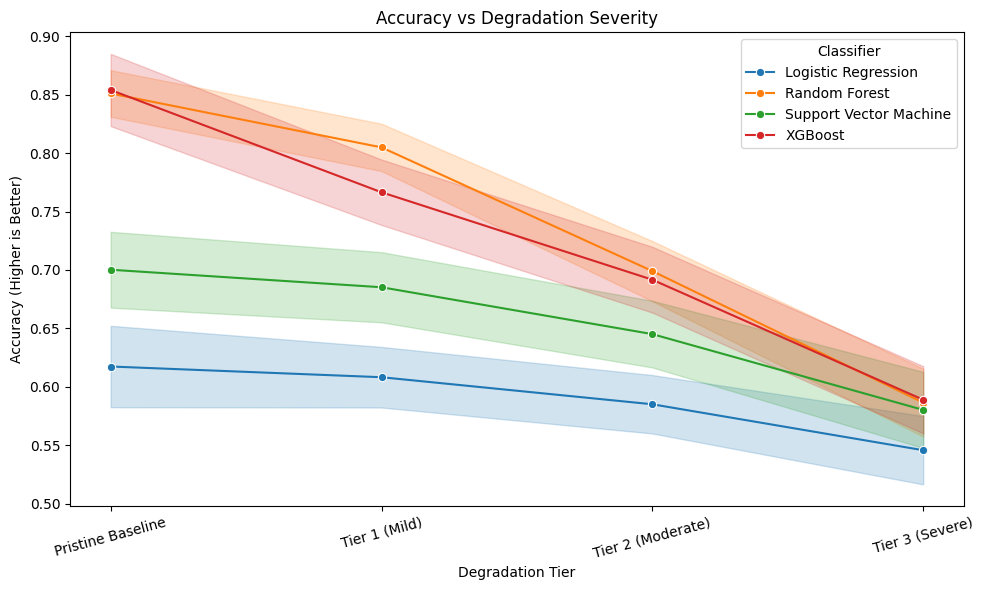

Saved -> results/figures/accuracy_vs_degradation.png


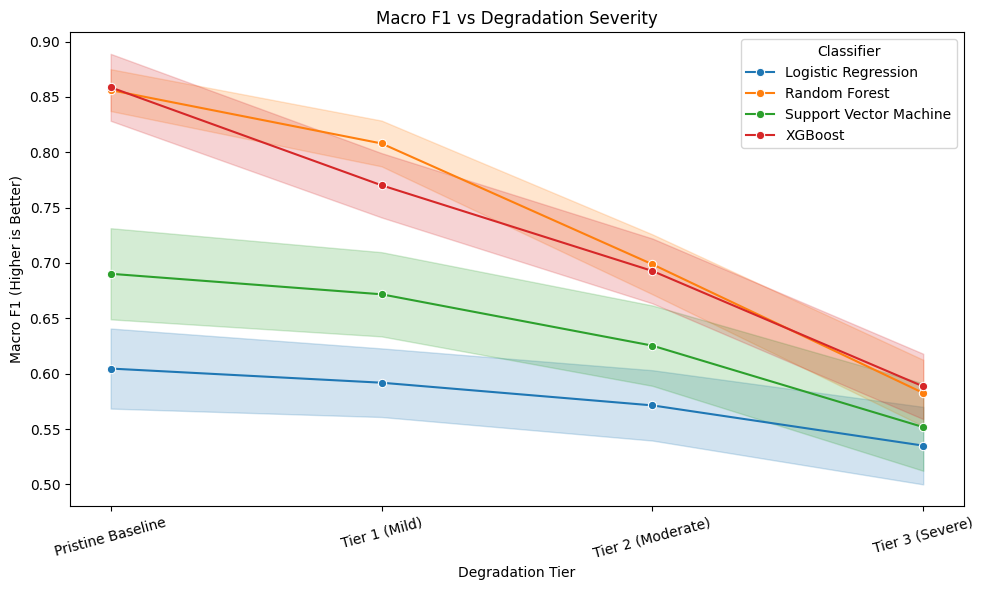

Saved -> results/figures/macro_f1_vs_degradation.png


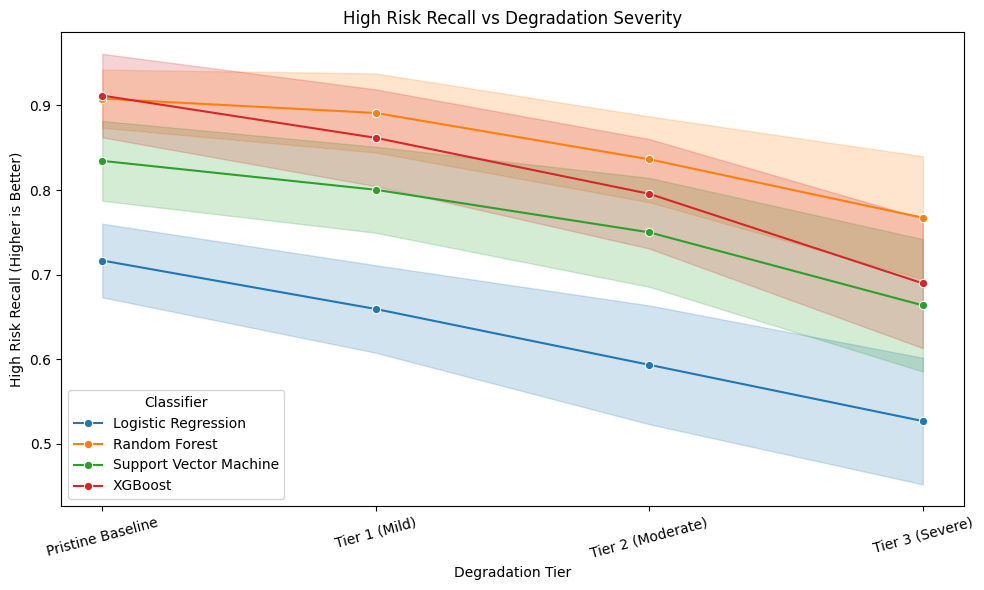

Saved -> results/figures/high_risk_recall_vs_degradation.png


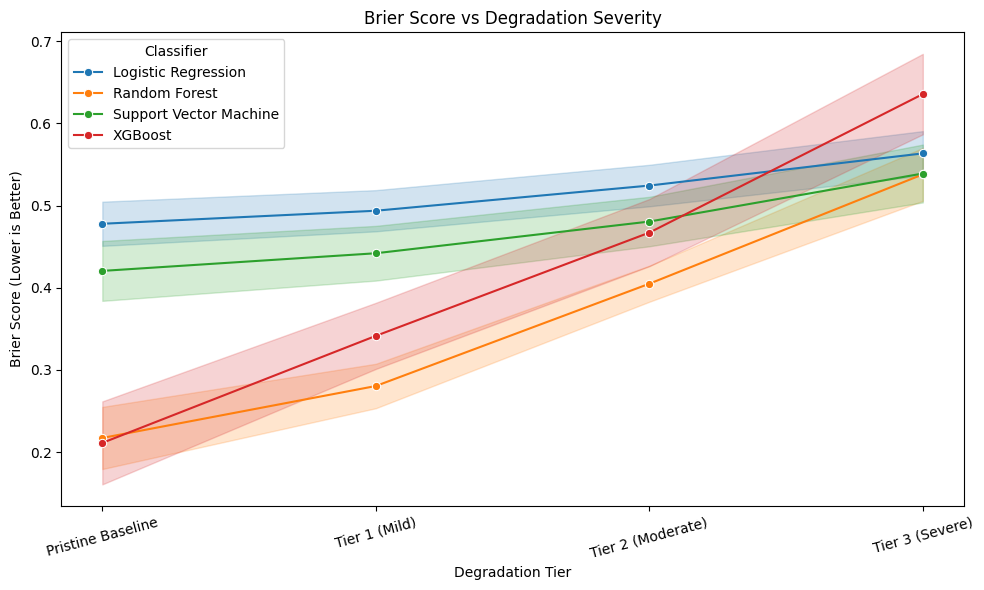

Saved -> results/figures/brier_score_vs_degradation.png


In [6]:
# --- Degradation Curve Figures ---
tier_order = list(TIERS.keys())
cv_df["Tier"] = pd.Categorical(cv_df["Tier"], categories=tier_order, ordered=True)

# Helper
def save_degradation_curve(metric, filename, lower_better=False):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=cv_df, x="Tier", y=metric, hue="Classifier",
                 marker='o', errorbar='sd')
    note = " (Lower is Better)" if lower_better else " (Higher is Better)"
    plt.title(f"{metric} vs Degradation Severity")
    plt.ylabel(metric + note)
    plt.xlabel("Degradation Tier")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f"../results/figures/{filename}", bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved -> results/figures/{filename}")

save_degradation_curve("Accuracy",          "accuracy_vs_degradation.png")
save_degradation_curve("Macro F1",          "macro_f1_vs_degradation.png")
save_degradation_curve("High Risk Recall",  "high_risk_recall_vs_degradation.png")
save_degradation_curve("Brier Score",       "brier_score_vs_degradation.png", lower_better=True)


<Figure size 1000x500 with 0 Axes>

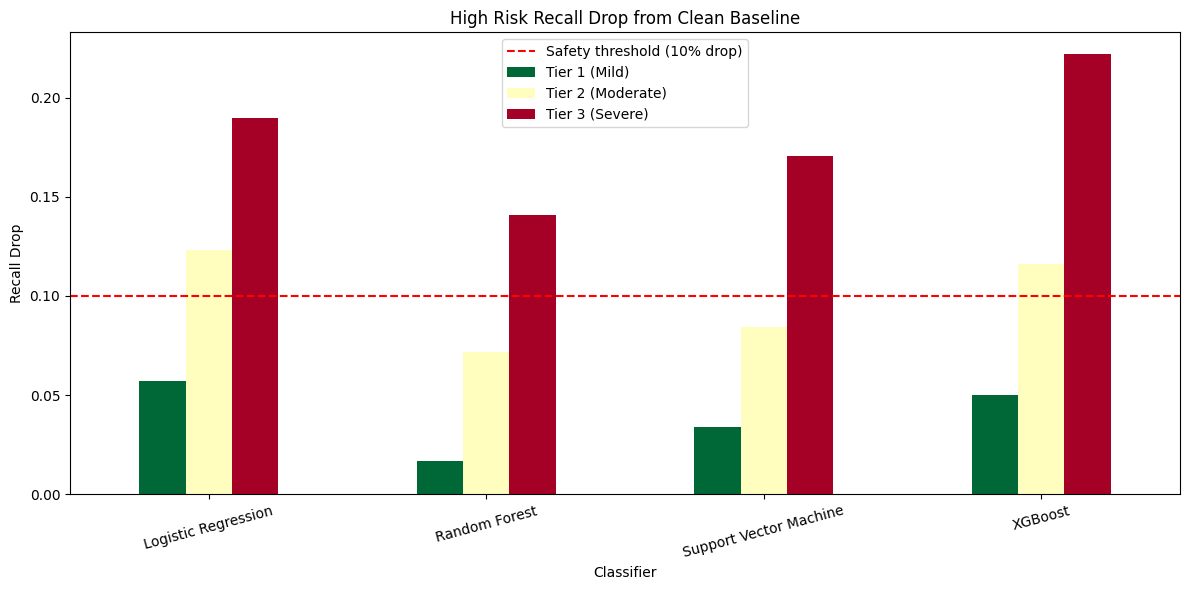

Saved -> results/figures/performance_drop.png


In [7]:
# --- Performance Drop Figure ---
pivot = drop_df.pivot(index="Classifier", columns="Tier", values="Recall Drop")
pivot = pivot[[c for c in tier_order if c in pivot.columns]]

plt.figure(figsize=(10, 5))
pivot.plot(kind="bar", figsize=(12, 6), colormap="RdYlGn_r")
plt.axhline(y=HIGH_RISK_RECALL_DROP_THRESHOLD, color='red', linestyle='--',
            label=f"Safety threshold ({HIGH_RISK_RECALL_DROP_THRESHOLD:.0%} drop)")
plt.title("High Risk Recall Drop from Clean Baseline")
plt.ylabel("Recall Drop")
plt.xlabel("Classifier")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/performance_drop.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved -> results/figures/performance_drop.png")


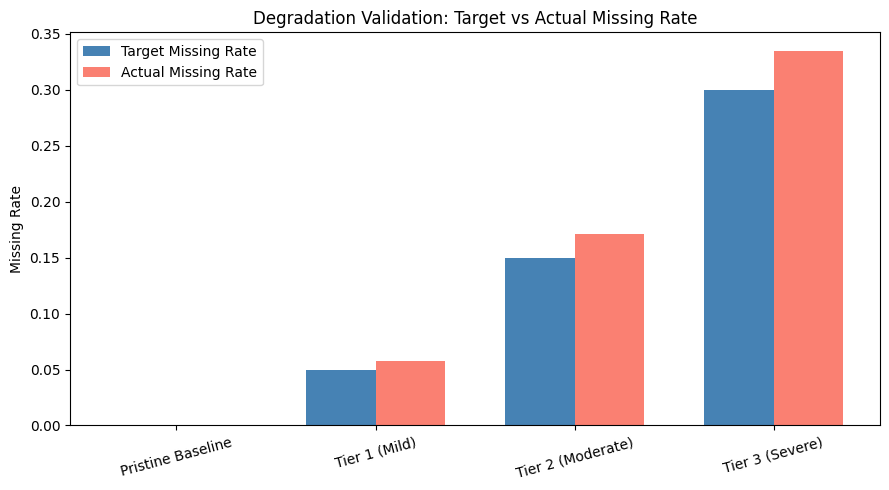

Saved -> results/figures/degradation_validation.png


In [8]:
# --- Degradation Validation Figure ---
# Requested vs actual missing rate per tier
val_summary = (
    cv_df.groupby("Tier")[["Missing_Rate_Target", "Actual_Missing_Rate"]]
    .mean()
    .reindex(tier_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(val_summary))
width = 0.35
ax.bar([i - width/2 for i in x], val_summary["Missing_Rate_Target"],
       width, label="Target Missing Rate", color='steelblue')
ax.bar([i + width/2 for i in x], val_summary["Actual_Missing_Rate"],
       width, label="Actual Missing Rate", color='salmon')
ax.set_xticks(list(x))
ax.set_xticklabels(val_summary.index, rotation=15)
ax.set_ylabel("Missing Rate")
ax.set_title("Degradation Validation: Target vs Actual Missing Rate")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/degradation_validation.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved -> results/figures/degradation_validation.png")


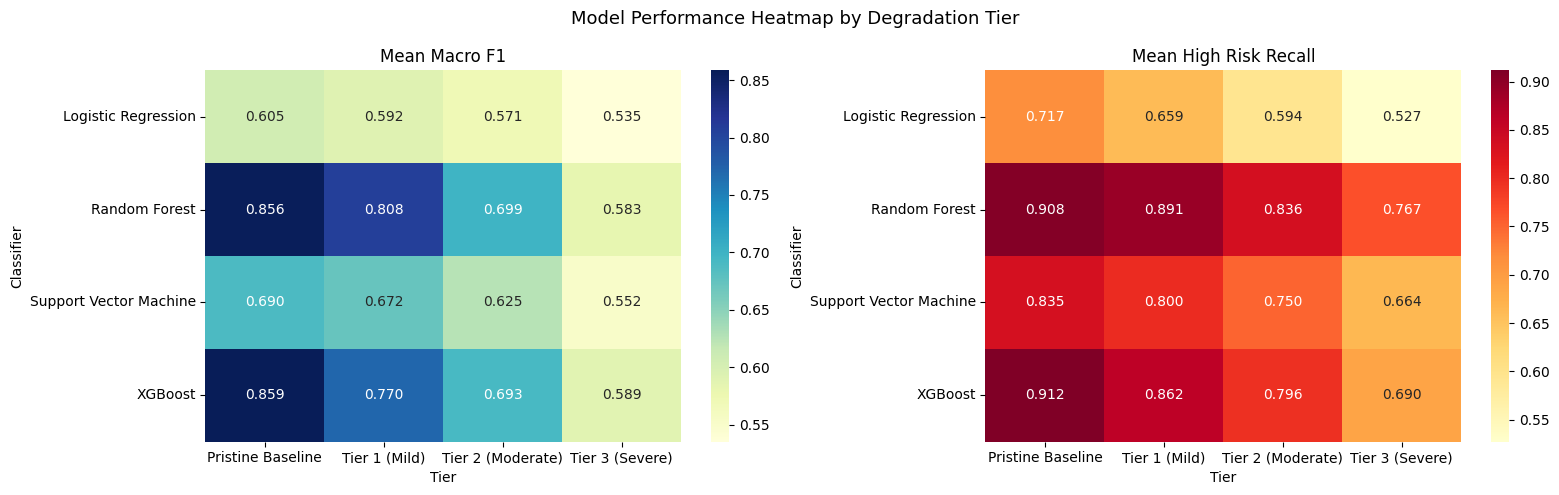

Saved -> results/figures/performance_heatmap.png


In [9]:
# --- Performance Heatmap ---
mean_f1     = cv_df.groupby(["Classifier", "Tier"])["Macro F1"].mean().unstack()
mean_recall = cv_df.groupby(["Classifier", "Tier"])["High Risk Recall"].mean().unstack()

# Reorder columns
for df_ in [mean_f1, mean_recall]:
    cols = [c for c in tier_order if c in df_.columns]
    df_ = df_[cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(mean_f1[tier_order], annot=True, fmt=".3f",
            cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean Macro F1")

sns.heatmap(mean_recall[tier_order], annot=True, fmt=".3f",
            cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Mean High Risk Recall")

plt.suptitle("Model Performance Heatmap by Degradation Tier", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/performance_heatmap.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved -> results/figures/performance_heatmap.png")


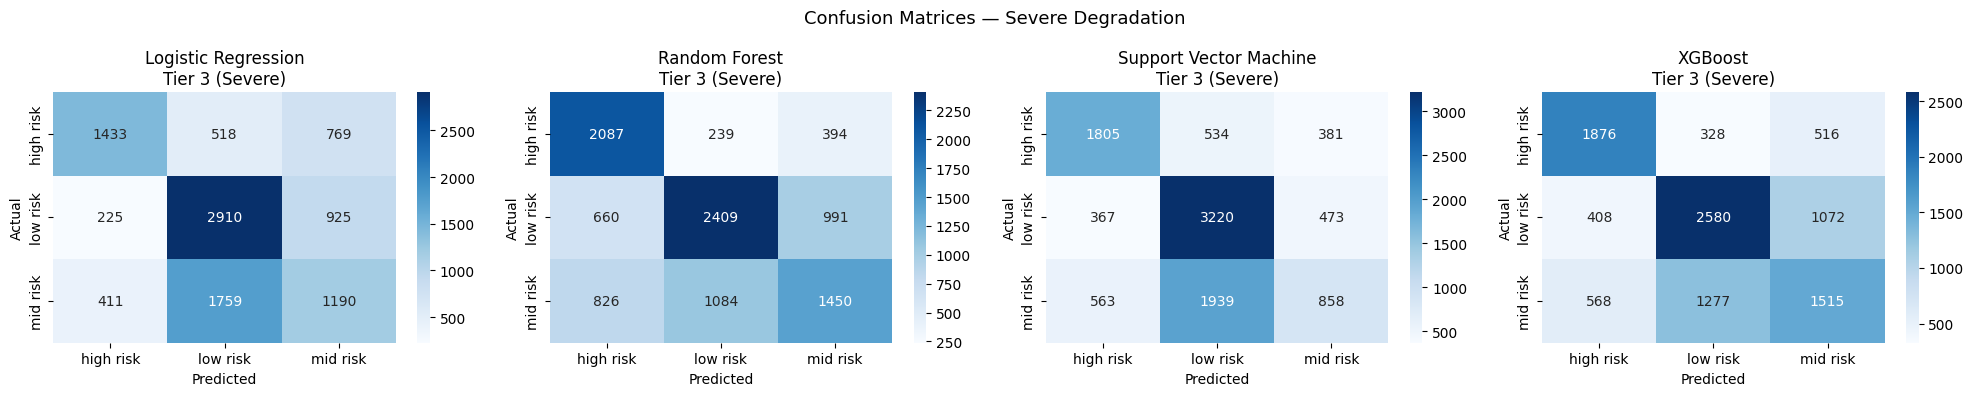

Saved -> results/figures/severe_confusion_matrix.png


In [10]:
# --- Severe Condition Confusion Matrices (Tier 3 only) ---
classes = ['high risk', 'low risk', 'mid risk']

n_cls = len(severe_cms)
fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 4))
if n_cls == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, severe_cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"{name}\nTier 3 (Severe)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Severe Degradation", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/severe_confusion_matrix.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved -> results/figures/severe_confusion_matrix.png")


## Unified Robustness Score (URS)

### Motivation

The metrics above (Accuracy, Macro F1, High-Risk Recall, Brier Score) are reported separately at each of the four degradation tiers. This is informative, but it does not directly answer a single question: **which classifier is most robust overall, across the full degradation spectrum?**

A comparison based only on clean-vs-severe endpoints can assign the same score to two models with very different degradation *shapes* — one that degrades gently and linearly, and another that stays flat until Tier 2 and then collapses. The **Unified Robustness Score (URS)** is a single summary metric designed to capture the entire degradation trajectory, not just the endpoints.

### Definition

For each metric $M$, we compute the **normalized Area Under the Degradation Curve (AUDC)** across the four ordered tiers (Pristine = 0, Mild = 1, Moderate = 2, Severe = 3) using trapezoidal integration:

$$AUDC(M) = \frac{\int_0^3 M(d)\,dd}{3}$$

Brier Score is a lower-is-better metric, so it is transformed to $1 - \text{Brier}$ before integration, so all four component AUDCs follow a higher-is-better convention.

The four component AUDCs are combined using **clinically motivated, project-specific weights** — High-Risk Recall receives the largest weight because failing to identify a genuinely high-risk maternal case is the costliest error type in this application:

$$URS = 0.40\,AUDC_{HRR} + 0.30\,AUDC_{MacroF1} + 0.20\,AUDC_{Accuracy} + 0.10\,AUDC_{1-Brier}$$

reported on a 0–100 scale. These weights are **not** claimed to be universally established by the literature — they are this project's clinically motivated choice, and a sensitivity analysis against alternative weighting schemes is included below.

**Important:** URS answers *"which model is most robust overall?"* — it does **not** answer *"at what degradation level does a model become unsafe?"*. That second question is already answered by the High-Risk Recall drop / safety-threshold analysis above, which is kept unchanged.


In [11]:
# --- URS Step 1: Aggregate raw results by Classifier x Tier ---
# NOTE:
# Pristine has 5 observations (one per CV fold), while each degraded
# tier has 50 observations (5 folds x 10 degradation seeds). This is
# expected: pristine bypasses the degradation-seed loop. Grouping by
# Classifier x Tier first collapses each tier into ONE representative
# mean performance point, so every tier contributes exactly one point
# to the degradation curve regardless of how many raw rows fed into it.

TIER_ORDER = {
    "Pristine Baseline": 0,
    "Tier 1 (Mild)": 1,
    "Tier 2 (Moderate)": 2,
    "Tier 3 (Severe)": 3,
}

urs_summary_input = (
    cv_df.groupby(["Classifier", "Tier"])[metrics_cols]
    .mean()
    .reset_index()
)

# Map string tier labels to a numeric ordinal index for AUDC integration.
# The original string 'Tier' column is left untouched for readability.
urs_summary_input["Tier_Index"] = urs_summary_input["Tier"].map(TIER_ORDER)

if urs_summary_input["Tier_Index"].isna().any():
    unknown_tiers = urs_summary_input.loc[
        urs_summary_input["Tier_Index"].isna(), "Tier"
    ].unique()
    raise ValueError(f"Unknown tier labels found: {unknown_tiers}")

# Brier Score is lower-is-better; invert so all components are higher-is-better.
urs_summary_input["1-Brier"] = 1.0 - urs_summary_input["Brier Score"]

print("Aggregated Classifier x Tier performance points:")
display(urs_summary_input)


Aggregated Classifier x Tier performance points:


,Classifier,Tier,Accuracy,Macro F1,High Risk Recall,Brier Score,Tier_Index,1-Brier
0,Logistic Regression,Pristine Baseline,0.617339,0.604637,0.716768,0.477885,0,0.522115
1,Logistic Regression,Tier 1 (Mild),0.608169,0.591862,0.659475,0.493736,1,0.506264
2,Logistic Regression,Tier 2 (Moderate),0.585007,0.571383,0.593515,0.524365,2,0.475635
3,Logistic Regression,Tier 3 (Severe),0.545668,0.535034,0.527064,0.563513,3,0.436487
4,Random Forest,Pristine Baseline,0.851110,0.856113,0.908081,0.217240,0,0.782760
5,Random Forest,Tier 1 (Mild),0.804946,0.807939,0.891138,0.280471,1,0.719529
6,Random Forest,Tier 2 (Moderate),0.699024,0.698806,0.836391,0.404932,2,0.595068
7,Random Forest,Tier 3 (Severe),0.586397,0.582611,0.767327,0.537975,3,0.462025
8,Support Vector Machine,Pristine Baseline,0.700190,0.690235,0.834545,0.420532,0,0.579468
9,Support Vector Machine,Tier 1 (Mild),0.685198,0.671720,0.800404,0.442008,1,0.557992


In [12]:
# --- URS Step 2: AUDC and URS calculation functions ---

def calculate_audc(values, x=None):
    '''Normalized area under the degradation curve via trapezoidal integration.'''
    values = np.asarray(values, dtype=float)
    if x is None:
        x = np.arange(len(values))
    x = np.asarray(x, dtype=float)

    try:
        area = np.trapezoid(values, x)
    except AttributeError:
        area = np.trapz(values, x)

    max_area = x[-1] - x[0]
    return area / max_area


URS_WEIGHTS = {
    "High Risk Recall": 0.40,
    "Macro F1":          0.30,
    "Accuracy":          0.20,
    "1-Brier":           0.10,
}

def calculate_urs(hrr_audc, macro_f1_audc, accuracy_audc, inverse_brier_audc):
    return (
        URS_WEIGHTS["High Risk Recall"] * hrr_audc
        + URS_WEIGHTS["Macro F1"]        * macro_f1_audc
        + URS_WEIGHTS["Accuracy"]        * accuracy_audc
        + URS_WEIGHTS["1-Brier"]         * inverse_brier_audc
    )

print("URS weights:", URS_WEIGHTS, "| sum =", sum(URS_WEIGHTS.values()))


URS weights: {'High Risk Recall': 0.4, 'Macro F1': 0.3, 'Accuracy': 0.2, '1-Brier': 0.1} | sum = 1.0


In [13]:
# --- URS Step 3: Calculate AUDC + URS per classifier ---
urs_results = []

for classifier in urs_summary_input["Classifier"].unique():
    model_data = (
        urs_summary_input[urs_summary_input["Classifier"] == classifier]
        .sort_values("Tier_Index")
    )

    # Sanity checks: every classifier must have exactly 4 tiers, 0-3.
    # If a tier is missing, stop rather than silently interpolating it.
    assert len(model_data) == 4, (
        f"{classifier}: expected 4 aggregated tier points, got {len(model_data)}"
    )
    assert set(model_data["Tier_Index"]) == {0, 1, 2, 3}, (
        f"{classifier}: missing tier(s) -- found {sorted(model_data['Tier_Index'])}"
    )

    x = model_data["Tier_Index"].to_numpy()

    audc_hrr           = calculate_audc(model_data["High Risk Recall"].to_numpy(), x)
    audc_macro_f1       = calculate_audc(model_data["Macro F1"].to_numpy(), x)
    audc_accuracy       = calculate_audc(model_data["Accuracy"].to_numpy(), x)
    audc_inverse_brier  = calculate_audc(model_data["1-Brier"].to_numpy(), x)

    for name, val in [("HRR", audc_hrr), ("Macro F1", audc_macro_f1),
                       ("Accuracy", audc_accuracy), ("1-Brier", audc_inverse_brier)]:
        assert 0 <= val <= 1, f"{classifier} {name} AUDC out of [0,1]: {val}"

    urs = calculate_urs(audc_hrr, audc_macro_f1, audc_accuracy, audc_inverse_brier)
    assert 0 <= urs <= 1, f"{classifier} URS out of [0,1]: {urs}"

    urs_results.append({
        "Classifier":              classifier,
        "AUDC_High_Risk_Recall":   audc_hrr,
        "AUDC_Macro_F1":           audc_macro_f1,
        "AUDC_Accuracy":           audc_accuracy,
        "AUDC_1_minus_Brier":      audc_inverse_brier,
        "URS":                     urs * 100,
    })

urs_summary = (
    pd.DataFrame(urs_results)
    .sort_values("URS", ascending=False)
    .reset_index(drop=True)
)
urs_summary["URS_Rank"] = np.arange(1, len(urs_summary) + 1)

urs_summary.to_csv("../results/tables/urs_summary.csv", index=False)

print("Unified Robustness Score (0-100, higher = more robust):")
display(urs_summary.round(4))
print("\nSaved -> results/tables/urs_summary.csv")


Unified Robustness Score (0-100, higher = more robust):


,Classifier,AUDC_High_Risk_Recall,AUDC_Macro_F1,AUDC_Accuracy,AUDC_1_minus_Brier,URS,URS_Rank
0,Random Forest,0.8551,0.7420,0.7409,0.6457,77.7389,1
1,XGBoost,0.8194,0.7288,0.7265,0.5893,75.0635,2
2,Support Vector Machine,0.7666,0.6394,0.6568,0.5325,68.3046,3
3,Logistic Regression,0.6250,0.5777,0.5916,0.4871,59.0314,4



Saved -> results/tables/urs_summary.csv


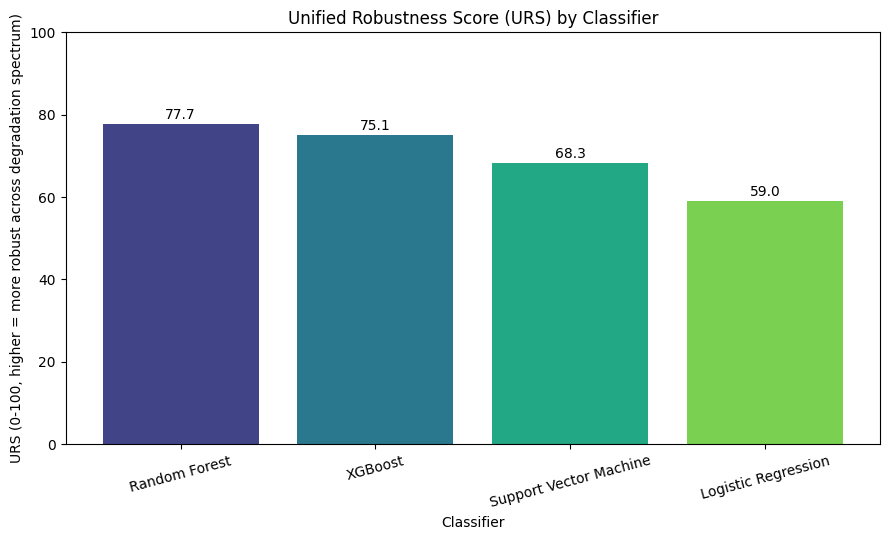

Saved -> results/figures/urs_comparison.png

Ranking (most to least robust):
  1. Random Forest             URS = 77.74
  2. XGBoost                   URS = 75.06
  3. Support Vector Machine    URS = 68.30
  4. Logistic Regression       URS = 59.03


In [14]:
# --- URS Step 4: Unified Robustness Score comparison plot ---
plt.figure(figsize=(9, 5.5))
order = urs_summary.sort_values("URS", ascending=False)
bars = plt.bar(order["Classifier"], order["URS"],
               color=sns.color_palette("viridis", len(order)))
for bar, val in zip(bars, order["URS"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:.1f}",
              ha="center", va="bottom", fontsize=10)

plt.title("Unified Robustness Score (URS) by Classifier")
plt.ylabel("URS (0-100, higher = more robust across degradation spectrum)")
plt.xlabel("Classifier")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../results/figures/urs_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved -> results/figures/urs_comparison.png")

print()
print("Ranking (most to least robust):")
for _, row in order.iterrows():
    print(f"  {int(row['URS_Rank'])}. {row['Classifier']:<25} URS = {row['URS']:.2f}")


In [15]:
# --- URS Step 5: Per-fold URS (uncertainty estimate) ---
# Aggregate seeds within each fold first (keep Fold separate), then
# compute one AUDC/URS per Classifier x Fold, and finally report
# mean +/- SD across folds. Each fold still contributes exactly one
# T0-T3 point per classifier to its own AUDC calculation -- this does
# not replace the primary tier-level aggregation used above, it adds
# an uncertainty estimate around it.

fold_summary = (
    cv_df.groupby(["Classifier", "Fold", "Tier"])[metrics_cols]
    .mean()
    .reset_index()
)
fold_summary["Tier_Index"] = fold_summary["Tier"].map(TIER_ORDER)
fold_summary["1-Brier"] = 1.0 - fold_summary["Brier Score"]

per_fold_urs = []
for (classifier, fold), grp in fold_summary.groupby(["Classifier", "Fold"]):
    grp = grp.sort_values("Tier_Index")
    if len(grp) != 4 or set(grp["Tier_Index"]) != {0, 1, 2, 3}:
        continue  # incomplete fold -- should not happen, skip defensively

    x = grp["Tier_Index"].to_numpy()
    urs_fold = calculate_urs(
        calculate_audc(grp["High Risk Recall"].to_numpy(), x),
        calculate_audc(grp["Macro F1"].to_numpy(), x),
        calculate_audc(grp["Accuracy"].to_numpy(), x),
        calculate_audc(grp["1-Brier"].to_numpy(), x),
    ) * 100

    per_fold_urs.append({"Classifier": classifier, "Fold": fold, "URS": urs_fold})

per_fold_urs_df = pd.DataFrame(per_fold_urs)

urs_uncertainty = (
    per_fold_urs_df.groupby("Classifier")["URS"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "URS_Mean", "std": "URS_SD"})
    .sort_values("URS_Mean", ascending=False)
)

print("URS uncertainty across CV folds (mean +/- SD):")
for clf, row in urs_uncertainty.iterrows():
    print(f"  {clf:<25} URS = {row['URS_Mean']:.2f} +/- {row['URS_SD']:.2f}")

urs_uncertainty.to_csv("../results/tables/urs_uncertainty.csv")
print("\nSaved -> results/tables/urs_uncertainty.csv")


URS uncertainty across CV folds (mean +/- SD):
  Random Forest             URS = 77.74 +/- 2.14
  XGBoost                   URS = 75.06 +/- 3.20
  Support Vector Machine    URS = 68.30 +/- 3.77
  Logistic Regression       URS = 59.03 +/- 2.88

Saved -> results/tables/urs_uncertainty.csv


URS under alternative weighting schemes:


Weight_Config,A: Clinical priority (proposed),B: Equal weights,C: Recall + F1 dominant
Classifier,,,
Logistic Regression,59.03,57.03,59.42
Random Forest,77.74,74.59,78.23
Support Vector Machine,68.30,64.88,68.75
XGBoost,75.06,71.60,75.77



Rank under alternative weighting schemes (1 = most robust):


Weight_Config,A: Clinical priority (proposed),B: Equal weights,C: Recall + F1 dominant
Classifier,,,
Logistic Regression,4,4,4
Random Forest,1,1,1
Support Vector Machine,3,3,3
XGBoost,2,2,2



Top-ranked classifier is STABLE across weight configurations.
-> Random Forest is the most robust model regardless of weighting scheme.

Saved -> results/tables/urs_weight_sensitivity.csv


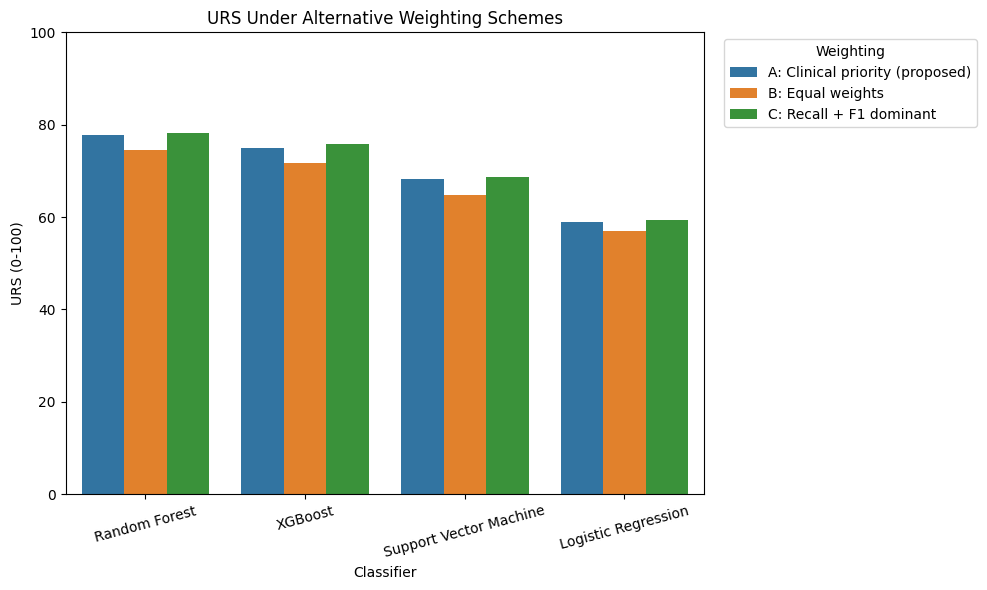

Saved -> results/figures/urs_weight_sensitivity.png


In [16]:
# --- URS Step 6: Weight sensitivity analysis ---
# Test whether the model ranking changes under alternative weighting
# schemes. If the ranking is stable, the URS conclusion is not highly
# sensitive to the exact 40/30/20/10 choice. Weights are 0.40/0.30/0.20/0.10
# on High-Risk Recall / Macro F1 / Accuracy / 1-Brier respectively for
# Config A -- see URS_WEIGHTS above.

WEIGHT_CONFIGS = {
    "A: Clinical priority (proposed)": {"HRR": 0.40, "Macro F1": 0.30, "Accuracy": 0.20, "1-Brier": 0.10},
    "B: Equal weights":                {"HRR": 0.25, "Macro F1": 0.25, "Accuracy": 0.25, "1-Brier": 0.25},
    "C: Recall + F1 dominant":         {"HRR": 0.40, "Macro F1": 0.40, "Accuracy": 0.15, "1-Brier": 0.05},
}

sensitivity_rows = []
for config_name, w in WEIGHT_CONFIGS.items():
    for _, row in urs_summary.iterrows():
        score = (
            w["HRR"]        * row["AUDC_High_Risk_Recall"]
            + w["Macro F1"] * row["AUDC_Macro_F1"]
            + w["Accuracy"] * row["AUDC_Accuracy"]
            + w["1-Brier"]  * row["AUDC_1_minus_Brier"]
        ) * 100
        sensitivity_rows.append({
            "Weight_Config": config_name,
            "Classifier": row["Classifier"],
            "URS": score,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df["Rank"] = (
    sensitivity_df.groupby("Weight_Config")["URS"]
    .rank(ascending=False, method="min")
    .astype(int)
)

sensitivity_pivot = sensitivity_df.pivot(index="Classifier", columns="Weight_Config", values="URS")
rank_pivot = sensitivity_df.pivot(index="Classifier", columns="Weight_Config", values="Rank")

print("URS under alternative weighting schemes:")
display(sensitivity_pivot.round(2))
print("\nRank under alternative weighting schemes (1 = most robust):")
display(rank_pivot)

top_per_config = rank_pivot.idxmin()
stable = top_per_config.nunique() == 1
print(f"\nTop-ranked classifier is {'STABLE' if stable else 'NOT stable'} across weight configurations.")
if stable:
    print(f"-> {top_per_config.iloc[0]} is the most robust model regardless of weighting scheme.")
else:
    print(f"-> Top model varies by configuration: {top_per_config.to_dict()}")

sensitivity_df.to_csv("../results/tables/urs_weight_sensitivity.csv", index=False)
print("\nSaved -> results/tables/urs_weight_sensitivity.csv")

# --- Weight sensitivity plot ---
plt.figure(figsize=(10, 6))
sns.barplot(data=sensitivity_df, x="Classifier", y="URS", hue="Weight_Config")
plt.title("URS Under Alternative Weighting Schemes")
plt.ylabel("URS (0-100)")
plt.xlabel("Classifier")
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.legend(title="Weighting", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/urs_weight_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved -> results/figures/urs_weight_sensitivity.png")


In [17]:
print("=" * 50)
print("EXPERIMENT COMPLETE")
print("=" * 50)
print(f"  Folds:   {N_SPLITS}")
print(f"  Seeds:   {len(DEGRADATION_SEEDS)}")
print(f"  Tiers:   {list(TIERS.keys())}")
print(f"  Models:  {cv_df['Classifier'].unique().tolist()}")
print()
print("Saved outputs:")
print("  CSV    -> results/csv/robustness_results.csv")
print("  Tables -> results/tables/robustness_summary.csv")
print("          -> results/tables/model_comparison.csv")
print("          -> results/tables/degradation_summary.csv")
print("  Figures-> results/figures/accuracy_vs_degradation.png")
print("          -> results/figures/macro_f1_vs_degradation.png")
print("          -> results/figures/high_risk_recall_vs_degradation.png")
print("          -> results/figures/brier_score_vs_degradation.png")
print("          -> results/figures/performance_drop.png")
print("          -> results/figures/degradation_validation.png")
print("          -> results/figures/performance_heatmap.png")
print("          -> results/figures/severe_confusion_matrix.png")
print("  URS    -> results/tables/urs_summary.csv")
print("          -> results/tables/urs_uncertainty.csv")
print("          -> results/tables/urs_weight_sensitivity.csv")
print("          -> results/figures/urs_comparison.png")
print("          -> results/figures/urs_weight_sensitivity.png")


EXPERIMENT COMPLETE
  Folds:   5
  Seeds:   10
  Tiers:   ['Pristine Baseline', 'Tier 1 (Mild)', 'Tier 2 (Moderate)', 'Tier 3 (Severe)']
  Models:  ['Logistic Regression', 'Random Forest', 'Support Vector Machine', 'XGBoost']

Saved outputs:
  CSV    -> results/csv/robustness_results.csv
  Tables -> results/tables/robustness_summary.csv
          -> results/tables/model_comparison.csv
          -> results/tables/degradation_summary.csv
  Figures-> results/figures/accuracy_vs_degradation.png
          -> results/figures/macro_f1_vs_degradation.png
          -> results/figures/high_risk_recall_vs_degradation.png
          -> results/figures/brier_score_vs_degradation.png
          -> results/figures/performance_drop.png
          -> results/figures/degradation_validation.png
          -> results/figures/performance_heatmap.png
          -> results/figures/severe_confusion_matrix.png
  URS    -> results/tables/urs_summary.csv
          -> results/tables/urs_uncertainty.csv
          -> re